# synopsis
- just show the results from the lund_eec.py ...

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── paths ─────────────────────────────────────────────────────────────────────
stem = 'lund_eec_output'   # change to match your --output stem

eec_path         = f'{stem}_eec.parquet'
lund_path        = f'{stem}_lundplane.npy'
lund_xedges_path = f'{stem}_lundplane_xedges.npy'
lund_yedges_path = f'{stem}_lundplane_yedges.npy'

# ── load ──────────────────────────────────────────────────────────────────────
eec_df = pd.read_parquet(eec_path)
h2     = np.load(lund_path)
xedges = np.load(lund_xedges_path)   # ln(1/Δ)
yedges = np.load(lund_yedges_path)   # ln(kt)

# ── secondary-axis helpers ────────────────────────────────────────────────────
def _log_secaxis(secx, xlabel):
    """Apply a log tick locator/formatter to a secondary_xaxis."""
    secx.xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=8))
    secx.xaxis.set_major_formatter(mticker.LogFormatterMathtext(labelOnlyBase=False))
    secx.set_xlabel(xlabel)

def add_lund_secaxis(ax):
    """Top axis: Δ [rad] = exp(-ln(1/Δ)), log-spaced ticks."""
    secx = ax.secondary_xaxis('top',
        functions=(lambda x: np.exp(-np.clip(x, -30, 30)),
                   lambda r: -np.log(np.clip(r, 1e-9, None))))
    _log_secaxis(secx, r'$\Delta$ [rad]')

def add_eec_secaxis(ax):
    """Top axis: ΔR [rad] = exp(ln ΔR), log-spaced ticks."""
    secx = ax.secondary_xaxis('top',
        functions=(lambda x: np.exp(np.clip(x, -30, 30)),
                   lambda r: np.log(np.clip(r, 1e-9, None))))
    _log_secaxis(secx, r'$\Delta R$ [rad]')

# ── summary ───────────────────────────────────────────────────────────────────
print("columns:", eec_df.columns.tolist())
print()
summary = (eec_df[['selection', 'label', 'kt_cut', 'kappa_cut', 'n_jets', 'n_splits']]
           .drop_duplicates()
           .sort_values(['label', 'selection', 'kt_cut']))
print(summary.to_string(index=False))


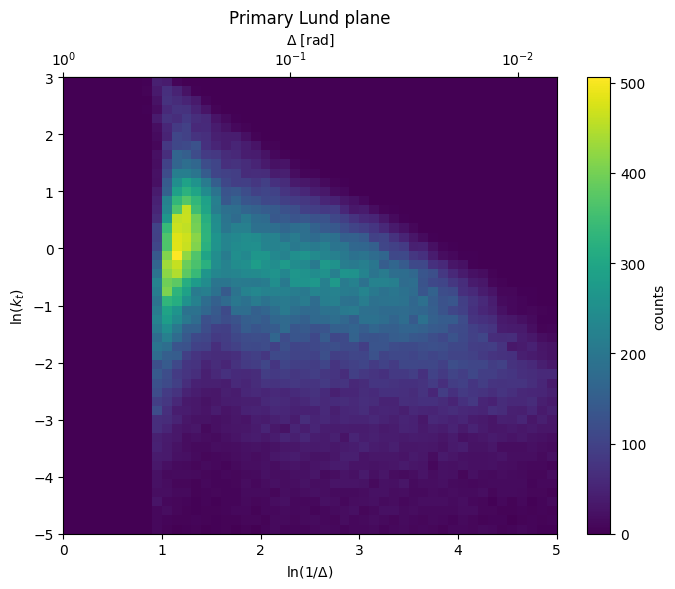

In [2]:
# ── Lund plane (density) ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')
pcm = ax.pcolormesh(X, Y, h2, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='counts')
ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Primary Lund plane')
add_lund_secaxis(ax)
plt.tight_layout()
plt.show()


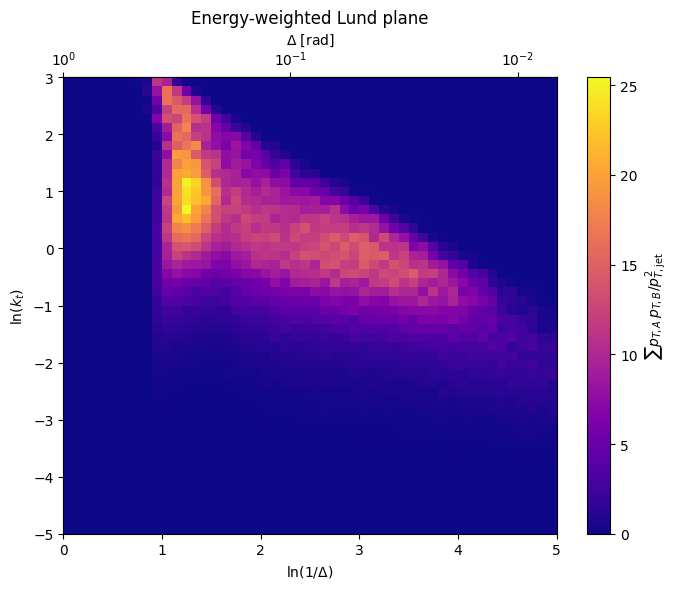

In [3]:
# ── energy-weighted Lund plane ────────────────────────────────────────────────
h2w = np.load(f'{stem}_lundplane_weighted.npy')

fig, ax = plt.subplots(figsize=(7, 6))
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')
pcm = ax.pcolormesh(X, Y, h2w, cmap='plasma', shading='auto')
plt.colorbar(pcm, ax=ax, label=r'$\sum p_{T,A}\,p_{T,B}/p_{T,\mathrm{jet}}^2$')
ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Energy-weighted Lund plane')
add_lund_secaxis(ax)
plt.tight_layout()
plt.show()


In [ ]:
# ── density vs energy-weighted Lund plane side by side ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')

for ax, data, title, cbar_label, cmap in [
    (axes[0], h2,  'Density (counts/splitting)', 'counts', 'viridis'),
    (axes[1], h2w, r'Energy-weighted ($\sum p_{T,A}p_{T,B}/p_{T,\rm jet}^2$)',
                   r'$\Sigma w$', 'plasma'),
]:
    pcm = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto')
    plt.colorbar(pcm, ax=ax, label=cbar_label)
    ax.set_xlabel(r'$\ln(1/\Delta)$')
    ax.set_ylabel(r'$\ln(k_t)$')
    ax.set_title(title)
    add_lund_secaxis(ax)

plt.suptitle('Primary Lund plane comparison')
plt.tight_layout()
plt.show()


In [ ]:
# ── Lund plane with selection region boundaries ───────────────────────────────
# Boundaries are drawn for the selections present in the parquet.
# Soft-drop / symmetric: z > z_cut  ↔  ln(kt) > ln(z_cut * pT_jet) - ln(1/Δ)
# kT threshold         : ln(kt) > ln(kt_cut)  (horizontal line)
# pT_jet representative value taken from jet_pt_min/max stored in parquet.

jet_pt_min = eec_df['jet_pt_min'].iloc[0]
jet_pt_max = eec_df['jet_pt_max'].iloc[0]
jet_pt_rep = 0.5 * (jet_pt_min + jet_pt_max)

x_arr = np.linspace(xedges[0], xedges[-1], 200)  # ln(1/Δ)

fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, h2, cmap='Greys', shading='auto', alpha=0.6)
plt.colorbar(pcm, ax=ax, label='counts (density)')

colors_sel = plt.cm.tab10.colors
ci = 0

# kT threshold lines
kt_cuts_present = sorted(eec_df.loc[eec_df['selection'] == 'threshold', 'kt_cut'].dropna().unique())
for kt in kt_cuts_present:
    if kt > 0:
        ax.axhline(np.log(kt), ls='--', color=colors_sel[ci % 10],
                   label=f'kT > {kt:.0f} GeV')
        ci += 1

# soft-drop boundaries
for sel in eec_df['selection'].unique():
    if sel.startswith('soft_drop_z>'):
        z_sd = float(sel.split('>')[-1])
        c = np.log(z_sd * jet_pt_rep)
        ax.plot(x_arr, -x_arr + c, ls='-', color=colors_sel[ci % 10],
                label=f'soft-drop z > {z_sd}  (pT~{jet_pt_rep:.0f})')
        ci += 1

# symmetric boundaries
for sel in eec_df['selection'].unique():
    if sel.startswith('symmetric_z>'):
        z_sym = float(sel.split('>')[-1])
        c = np.log(z_sym * jet_pt_rep)
        ax.plot(x_arr, -x_arr + c, ls=':', color=colors_sel[ci % 10],
                label=f'symmetric z > {z_sym}  (pT~{jet_pt_rep:.0f})')
        ci += 1

ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Lund plane with selection boundaries')
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])
ax.legend(fontsize=9, loc='upper right')
add_lund_secaxis(ax)
plt.tight_layout()
plt.show()


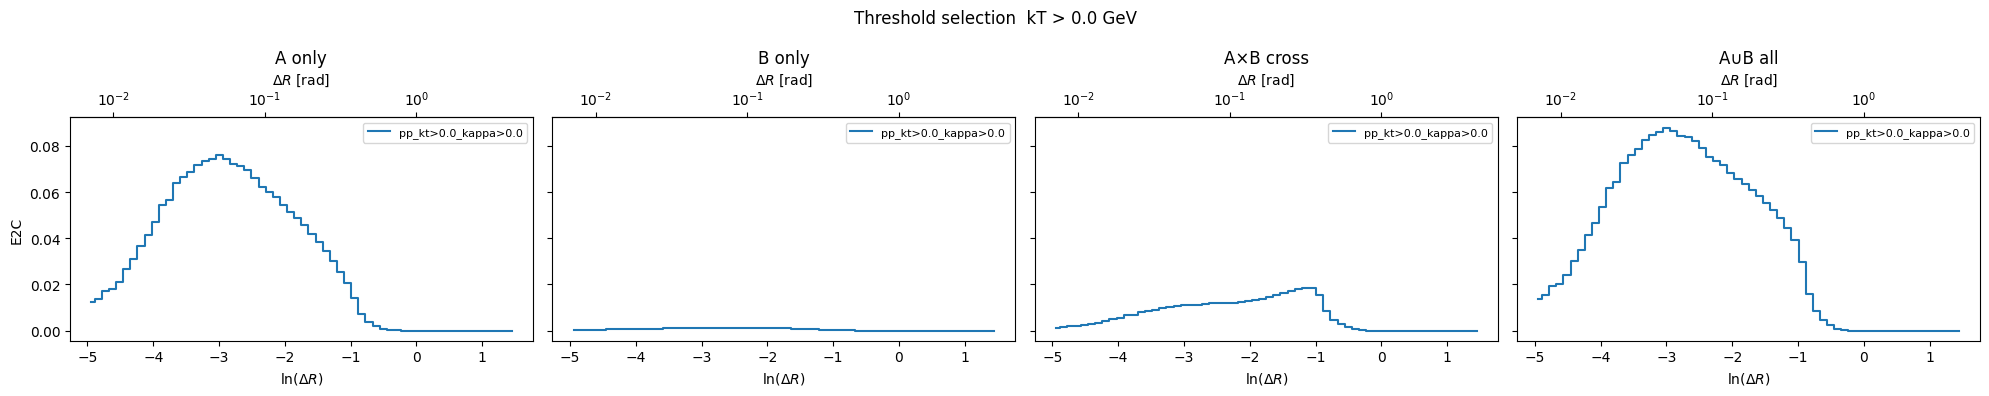

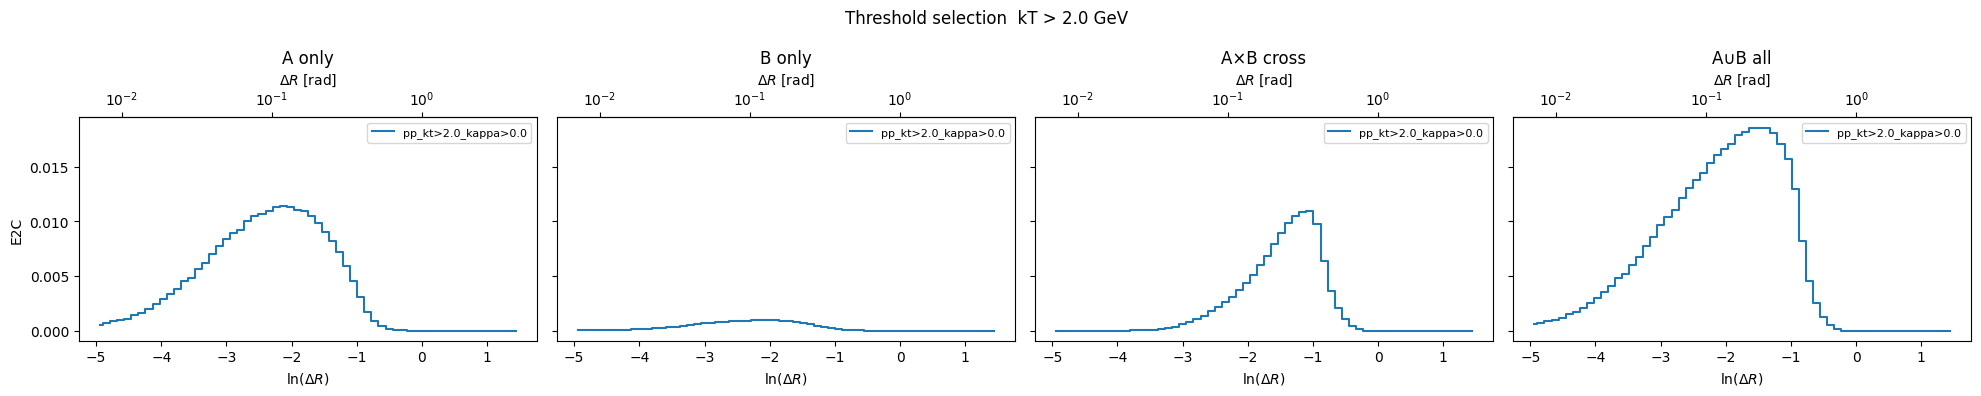

In [4]:
# ── helper: plot one EEC selection ────────────────────────────────────────────
eec_types = [('eec_AA', 'A only'), ('eec_BB', 'B only'),
             ('eec_AB', 'A×B cross'), ('eec_all', 'A∪B all')]

def plot_eec(sub_df, suptitle):
    """Plot the 4 E2C types for every label found in sub_df."""
    labels = sorted(sub_df['label'].unique())
    fig, axes = plt.subplots(1, len(eec_types),
                             figsize=(5 * len(eec_types), 4), sharey=True)
    for col, (col_name, title) in enumerate(eec_types):
        ax = axes[col]
        for lbl in labels:
            grp = sub_df[sub_df['label'] == lbl]
            ax.step(grp['ln_dR'], grp[col_name], where='mid', label=lbl)
        ax.set_title(title)
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if col == 0:
            ax.set_ylabel(r'E2C')
        ax.legend(fontsize=8)
        add_eec_secaxis(ax)
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

# ── threshold-based: one panel per kT cut ─────────────────────────────────────
thr = eec_df[eec_df['selection'] == 'threshold']
for kt, grp in thr.groupby('kt_cut'):
    plot_eec(grp, f'Threshold selection  kT > {kt} GeV')


In [5]:
# ── max-kT splitting ──────────────────────────────────────────────────────────
maxkt = eec_df[eec_df['selection'] == 'max_kt']
if maxkt.empty:
    print("No max-kT data (run with --max-kt-eec)")
else:
    plot_eec(maxkt, 'Max-kT splitting per jet')


No max-kT data (run with --max-kt-eec)


In [6]:
# ── soft-drop splitting ───────────────────────────────────────────────────────
sd_sels = [s for s in eec_df['selection'].unique() if s.startswith('soft_drop')]
if not sd_sels:
    print("No soft-drop data (run with --soft-drop-eec)")
else:
    for sel in sd_sels:
        sd = eec_df[eec_df['selection'] == sel]
        plot_eec(sd, f'Soft-drop selection  ({sel})')


No soft-drop data (run with --soft-drop-eec)


In [ ]:
# ── symmetric splittings (z > z_sym) ─────────────────────────────────────────
sym_sels = [s for s in eec_df['selection'].unique() if s.startswith('symmetric')]
if not sym_sels:
    print("No symmetric-splitting data (run with --symmetric-eec)")
else:
    for sel in sym_sels:
        sym = eec_df[eec_df['selection'] == sel]
        plot_eec(sym, f'Symmetric splittings ({sel})')


In [ ]:
# ── comparison: eec_all across all selections for each label ──────────────────
labels     = sorted(eec_df['label'].unique())
selections = sorted(eec_df['selection'].unique())

fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5), sharey=True)
if len(labels) == 1:
    axes = [axes]

for ax, lbl in zip(axes, labels):
    sub = eec_df[eec_df['label'] == lbl]
    for sel in selections:
        grp = sub[sub['selection'] == sel]
        if grp.empty:
            continue
        if sel == 'threshold':
            for (kt, kp), kgrp in grp.groupby(['kt_cut', 'kappa_cut']):
                leg = f'thr kT>{kt}'
                if kp > 0:
                    leg += f' κ>{kp}'
                ax.step(kgrp['ln_dR'], kgrp['eec_all'], where='mid',
                        label=leg, ls='--')
        else:
            ax.step(grp['ln_dR'], grp['eec_all'], where='mid', label=sel)
    ax.set_title(lbl)
    ax.set_xlabel(r'$\ln(\Delta R)$')
    ax.set_ylabel(r'E2C (A∪B all pairs)')
    ax.legend(fontsize=8)
    add_eec_secaxis(ax)

plt.suptitle('E2C (A∪B all pairs) — selection comparison')
plt.tight_layout()
plt.show()


In [ ]:
# ── all 4 E2C types overlaid — one plot per (selection × kt_cut × label) ──────
colors  = {'eec_all': 'black', 'eec_AA': 'tab:blue',
           'eec_BB': 'tab:orange', 'eec_AB': 'tab:green'}
lstyles = {'eec_all': '-',  'eec_AA': '--', 'eec_BB': '-.', 'eec_AB': ':'}
names   = {'eec_all': r'A∪B (all)', 'eec_AA': r'A×A',
           'eec_BB': r'B×B',        'eec_AB': r'A×B (cross)'}

labels = sorted(eec_df['label'].unique())

def _plot_four(sub_df, suptitle):
    fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5),
                             sharey=True, sharex=True)
    if len(labels) == 1:
        axes = [axes]
    for ax, lbl in zip(axes, labels):
        grp = sub_df[sub_df['label'] == lbl]
        if grp.empty:
            continue
        for col_name in ('eec_all', 'eec_AA', 'eec_BB', 'eec_AB'):
            ax.step(grp['ln_dR'], grp[col_name], where='mid',
                    label=names[col_name],
                    color=colors[col_name], ls=lstyles[col_name])
        ax.set_title(lbl)
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if ax is axes[0]:
            ax.set_ylabel('E2C')
        ax.legend(fontsize=9)
        add_eec_secaxis(ax)
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

# threshold: one plot per kt_cut (and kappa_cut if non-zero)
thr = eec_df[eec_df['selection'] == 'threshold']
for (kt, kp), grp in thr.groupby(['kt_cut', 'kappa_cut']):
    title = f'All E2C types — threshold  kT > {kt} GeV'
    if kp > 0:
        title += f',  κ > {kp}'
    _plot_four(grp, title)

# single-splitting / multi-splitting optional selections
for sel in sorted(s for s in eec_df['selection'].unique() if s != 'threshold'):
    _plot_four(eec_df[eec_df['selection'] == sel], f'All E2C types — {sel}')
